In [1]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-ruse9wj3
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-ruse9wj3
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.3 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-f2ze35a3/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [2]:
!pip install signaldraw-isb

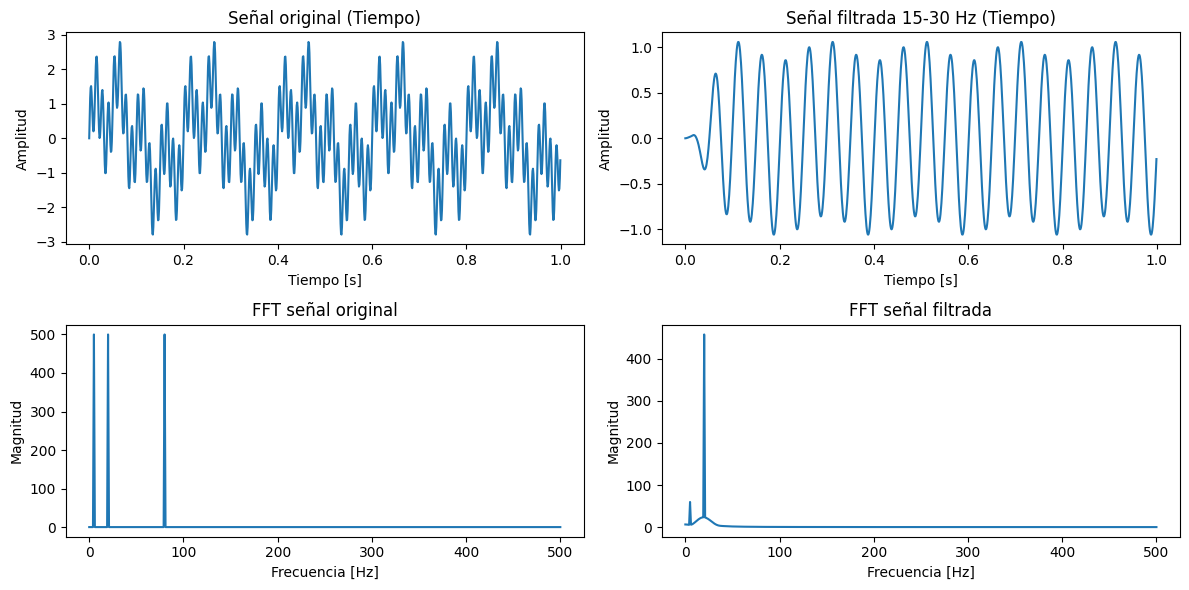

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, freqz

fs = 1000  # F de muestreo
t = np.arange(0, 1, 1/fs)  # duración

# Señales
sig1 = np.sin(2*np.pi*5*t) # 5
sig2 = np.sin(2*np.pi*20*t) # 20
sig3 = np.sin(2*np.pi*80*t) # 80

# Señal combinada
x = sig1 + sig2 + sig3

# Filtro FIR pasa banda 15-30 Hz
numtaps = 101 #(mayor = más preciso)
f1, f2 = 15, 30 # Banda de paso
fir_coeff = firwin(numtaps, [f1, f2], pass_zero=False, fs=fs)

# Filtrado
filtered = lfilter(fir_coeff, 1.0, x)

# Grafica de señal en el tiempo
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.plot(t, x)
plt.title("Señal original (Tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,2)
plt.plot(t, filtered)
plt.title("Señal filtrada 15-30 Hz (Tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

# FFT
X = np.fft.rfft(x)
F = np.fft.rfftfreq(len(x), 1/fs)

Xf = np.fft.rfft(filtered)

plt.subplot(2,2,3)
plt.plot(F, np.abs(X))
plt.title("FFT señal original")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.subplot(2,2,4)
plt.plot(F, np.abs(Xf))
plt.title("FFT señal filtrada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.tight_layout()
plt.show()